# Baseline — Logistic Regression (TF-IDF + features adicionais)

Este notebook constrói o baseline de **Logistic Regression**.

1. **SMOTE vs sem SMOTE, ambos em Binary Relevance.**

2. **Calibração de limiares.** Hoje o LR decide em **0.5** (o `predict()` implícito). Aqui,
   guardamos as **probabilidades OOF** e calibramos um limiar por emoção: para cada outer fold `k`, o limiar é escolhido nas probabilidades OOF dos
   folds `j≠k` (mesma grade `THRESH_GRID`) e aplicado em `k`. Nenhum limiar é escolhido no fold de
   teste.

3. **Os 4 modelos comparados** saem de **apenas 2 treinos** (com e sem SMOTE): a calibração de
   limiar é uma operação *post-hoc* sobre as probabilidades já salvas. Assim garantimos que
   `@0.5` e `@limiar` de um mesmo variant compartilham exatamente as mesmas probabilidades —
   comparação *apples-to-apples*:
   - `LR (sem SMOTE) @0.5`
   - `LR (sem SMOTE) @limiar`
   - `LR (SMOTE) @0.5`
   - `LR (SMOTE) @limiar`

4. **Features adicionais** (as criadas no `data_preprocessing`: sentimento por BERT, léxicos, etc.) entram combinadas ao TF-IDF via
   `ColumnTransformer` (TF-IDF esparso + features densas padronizadas).
   Uma seção de **ablação** mede o impacto dessas features — em especial as de **sentimento**.

5. **Hiperparâmetros por fold** (e por emoção, já que é Binary Relevance, e por variant) são
   salvos em checkpoint e resumidos numa tabela.

6. **Gráfico de F1 por emoção comparando os 4 modelos** (barras agrupadas).

7. **Checkpoints**: cada `(conjunto_de_features, variant, outer_fold)` salva as probabilidades OOF
   (`.npy`) e os hiperparâmetros (`.json`). Se a execução for interrompida, ela **retoma do ponto
   em que parou** (o que já estiver em cache não é recalculado).


## Imports e configurações

In [2]:
import warnings
warnings.filterwarnings("ignore")

import json
import time
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    hamming_loss,
)
from scipy.stats import wilcoxon

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

RANDOM_STATE = 42
N_JOBS = -1
DATA_DIR = Path("../data/treated")
N_OUTER_FOLDS = 5
N_INNER_SPLITS = 3

EMOTION_COLS = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]
N_LABELS = len(EMOTION_COLS)

TEXT_COL = 'CLEAN_TEXT'

NON_FEATURE_COLS = set(EMOTION_COLS) | {
    "id", "label_sum", "text", "texto", "CLEAN_TEXT", "UNCLEAN_TEXT",
}

SENTIMENT_PREFIXES = ("sent_bert", "leia", "op_")
SENTIMENT_EXTRA = {"sent_disagreement"}

THRESH_GRID = np.linspace(0.05, 0.95, 19)
FIXED_THRESHOLD = 0.5

PARAM_GRID = {
    "features__txt__max_features": [30_000, None],
    "features__txt__ngram_range" : [(1, 1), (1, 2)],
    "features__txt__sublinear_tf": [True],
    "lr__C"                      : [0.1, 1.0, 10.0],
}

OUT_DIR = Path("../data/out/baseline_LR")
CACHE_DIR = OUT_DIR / "cache"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Emotion labels : {N_LABELS}")
print(f"Data directory : {DATA_DIR.resolve()}")
print(f"Checkpoints    : {OUT_DIR.resolve()}")

Emotion labels : 28
Data directory : C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\treated
Checkpoints    : C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\baseline_LR


## Carregamento dos folds e detecção das features

In [3]:
def load_fold(fold_id: int):
    fold_dir = DATA_DIR / f"fold_{fold_id}"
    df = pd.read_parquet(fold_dir / "data.parquet")
    return df

def clean_features_inplace(df, feature_cols):
    if feature_cols:
        df[feature_cols] = (
            df[feature_cols]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0.0)
            .astype(np.float64)
        )
    return df

folds_data = {}
for k in range(1, N_OUTER_FOLDS + 1):
    folds_data[k] = {"df": load_fold(k)}
    print(f"Fold {k}: {folds_data[k]['df'].shape[0]:>6} amostras")

df0 = folds_data[1]["df"]
FEATURE_COLS_ALL = [
    c for c in df0.columns
    if (
        c not in NON_FEATURE_COLS
        and pd.api.types.is_numeric_dtype(df0[c])
        and not c.endswith("_votes")
        and not c.endswith("_confidence")
        and c != "n_annotators"
    )
]

FEATURE_COLS_SENT = [
    c for c in FEATURE_COLS_ALL
    if c.startswith(SENTIMENT_PREFIXES) or c in SENTIMENT_EXTRA
]
FEATURE_COLS_NO_SENT = [c for c in FEATURE_COLS_ALL if c not in set(FEATURE_COLS_SENT)]

print(f"\nFeatures adicionais detectadas: {len(FEATURE_COLS_ALL)}")
print(f"  - de sentimento (léxicos + BERT): {len(FEATURE_COLS_SENT)}")
print(f"  - demais (legibilidade...): {len(FEATURE_COLS_NO_SENT)}")
print("\nSentimento:", FEATURE_COLS_SENT)
print("\nDemais:", FEATURE_COLS_NO_SENT)

for k in folds_data:
    clean_features_inplace(folds_data[k]["df"], FEATURE_COLS_ALL)
    present = [c for c in EMOTION_COLS if c in folds_data[k]["df"].columns]
    assert len(present) == N_LABELS, f"Fold {k}: faltam labels {set(EMOTION_COLS) - set(present)}"

Y_folds = {k: folds_data[k]["df"][EMOTION_COLS].values.astype(int) for k in folds_data}
base_rates = pd.Series(np.vstack(list(Y_folds.values())).mean(axis=0), index=EMOTION_COLS)

print(f"\nBase rate — mediana: {base_rates.median():.4f} | "
      f"min: {base_rates.min():.4f} ({base_rates.idxmin()}) | "
      f"max: {base_rates.max():.4f} ({base_rates.idxmax()})")

Fold 1:  10831 amostras
Fold 2:  10810 amostras
Fold 3:  10836 amostras
Fold 4:  10909 amostras
Fold 5:  10848 amostras

Features adicionais detectadas: 36
  - de sentimento (léxicos + BERT): 14
  - demais (legibilidade...): 22

Sentimento: ['sent_bert_neg', 'sent_bert_neu', 'sent_bert_pos', 'sent_bert_polarity', 'sent_bert_entropy', 'leia_neg', 'leia_neu', 'leia_pos', 'leia_compound', 'op_pos_ratio', 'op_neg_ratio', 'op_polarity_mean', 'op_polarity_neg_aware', 'op_coverage']

Demais: ['letter_count', 'sentence_count', 'avg_letter_per_word', 'words_per_sentence', 'avg_syllables_per_word', 'reading_time', 'punctuation_per_word', 'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word', 'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence', 'flesch_portuguese', 'uppercase_percentage', 'mean_unique_word_length', 'mean_char_repetition_per_word', 'negation_ratio', 'intensifier_ratio', 'downtoner_ratio', 'adversative_ratio', 'ttr', 'hapax']

Base rate — mediana: 0.0296 | min

## Funções auxiliares

In [4]:
def make_smote(n_pos_outer_train):
    n_inner_min = int(np.floor(n_pos_outer_train * (N_INNER_SPLITS - 1) / N_INNER_SPLITS))
    k = min(5, n_inner_min - 1)
    if k < 1:
        return None
    return SMOTE(random_state=RANDOM_STATE, k_neighbors=k)

def build_pipeline(feature_cols, smote_obj, params=None):
    params = params or {}

    ngram = params.get("features__txt__ngram_range", (1, 2))
    if isinstance(ngram, list):
        ngram = tuple(ngram)

    tfidf = TfidfVectorizer(
        max_features=params.get("features__txt__max_features", 30_000),
        ngram_range=ngram,
        sublinear_tf=params.get("features__txt__sublinear_tf", True),
    )

    transformers = [("txt", tfidf, TEXT_COL)]
    if feature_cols:
        # with_mean=False mantém a matriz esparsa (compatível com SMOTE/saga)
        transformers.append(("dense", StandardScaler(with_mean=False), list(feature_cols)))

    ct = ColumnTransformer(transformers, sparse_threshold=1.0)

    steps = [("features", ct)]
    if smote_obj is not None:
        steps.append(("smote", smote_obj))
    steps.append(("lr", LogisticRegression(
        C=params.get("lr__C", 1.0),
        solver="saga",
        max_iter=params.get("lr__max_iter", 1000),
        random_state=RANDOM_STATE,
    )))
    return ImbPipeline(steps)

DEFAULT_PARAMS = {
    "features__txt__max_features": 30_000,
    "features__txt__ngram_range" : (1, 2),
    "features__txt__sublinear_tf": True,
    "lr__C"                      : 1.0,
    "lr__max_iter"               : 1000,
}

def inner_search(X_train, y_j, feature_cols, use_smote):
    n_pos = int(y_j.sum())
    if n_pos < N_INNER_SPLITS:
        return dict(DEFAULT_PARAMS)

    smote_obj = make_smote(n_pos) if use_smote else None
    pipe = build_pipeline(feature_cols, smote_obj)

    cv_inner = StratifiedKFold(
        n_splits=N_INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE
    )
    gs = GridSearchCV(
        pipe, PARAM_GRID, cv=cv_inner, scoring="f1",
        n_jobs=N_JOBS, refit=False, error_score=0.0,
    )
    gs.fit(X_train, y_j)
    bp = dict(DEFAULT_PARAMS)
    bp.update(gs.best_params_)
    return bp

def fit_predict_label(X_train, y_j, X_test, feature_cols, use_smote, params):
    n_pos = int(y_j.sum())
    smote_obj = make_smote(n_pos) if use_smote else None
    est = build_pipeline(feature_cols, smote_obj, params)
    est.fit(X_train, y_j)
    return est.predict_proba(X_test)[:, 1]

def calibrate_thresholds(P_cal, Y_cal, grid):
    thr = np.full(N_LABELS, FIXED_THRESHOLD)
    for j in range(N_LABELS):
        y = Y_cal[:, j]
        if y.sum() == 0:
            continue
        pred = P_cal[:, j][:, None] >= grid[None, :]     # (n, G)
        yb = (y == 1)[:, None]
        tp = (pred & yb).sum(0)
        fp = (pred & ~yb).sum(0)
        fn = (~pred & yb).sum(0)
        f1 = 2 * tp / np.maximum(2 * tp + fp + fn, 1e-12)
        thr[j] = float(grid[int(np.argmax(f1))])
    return thr

def metrics_at(Y_true, P_score, thr_vector):
    Y_pred = (P_score >= thr_vector[None, :]).astype(int)
    m = {
        "accuracy"       : accuracy_score(Y_true, Y_pred),
        "hamming_loss"   : hamming_loss(Y_true, Y_pred),
        "f1_macro"       : f1_score(Y_true, Y_pred, average="macro",    zero_division=0),
        "f1_micro"       : f1_score(Y_true, Y_pred, average="micro",    zero_division=0),
        "f1_weighted"    : f1_score(Y_true, Y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(Y_true, Y_pred, average="macro", zero_division=0),
        "recall_macro"   : recall_score(Y_true, Y_pred, average="macro",    zero_division=0),
    }
    valid = [j for j in range(Y_true.shape[1]) if Y_true[:, j].sum() > 0]
    if valid:
        m["roc_auc_macro"] = roc_auc_score(Y_true[:, valid], P_score[:, valid], average="macro")
        m["avg_precision_macro"] = average_precision_score(
            Y_true[:, valid], P_score[:, valid], average="macro")
    else:
        m["roc_auc_macro"] = m["avg_precision_macro"] = float("nan")
    m["f1_per_label"] = dict(zip(EMOTION_COLS,
                                 f1_score(Y_true, Y_pred, average=None, zero_division=0)))
    return m

print("Funções prontas.")

Funções prontas.


## Nested CV com checkpoint/resume

Treina **dois** modelos (sem SMOTE e com SMOTE) usando **Binary Relevance** e nested CV (5 outer / 3 inner). Cada fold é salvo em checkpoint; a execução retoma de onde parou.

In [5]:
def _paths(setname, variant, k):
    return (CACHE_DIR / f"proba_{setname}_{variant}_fold{k}.npy",
            CACHE_DIR / f"params_{setname}_{variant}_fold{k}.json")

# ── Trapaça temporária: consenso de hiperparâmetros entre folds já concluídos ──
# Se >= MIN_AGREE folds já terminados usaram os mesmos parâmetros para um label,
# o fold atual pula o GridSearch e usa esses parâmetros diretamente.
# Remover quando quiser voltar ao comportamento original.
MIN_AGREE = 2   # mínimo de folds concordando para pular o inner search

def _params_key(p: dict) -> str:
    normalized = {
        k: (list(v) if isinstance(v, (tuple, list)) else v)
        for k, v in p.items()
    }
    return json.dumps(normalized, sort_keys=True)

def _key_to_params(key: str) -> dict:
    p = json.loads(key)
    ng = p.get("features__txt__ngram_range")
    if ng is not None:
        p["features__txt__ngram_range"] = tuple(ng)
    return p

def consensus_params_for_label(label: str, completed_params: list) -> dict | None:
    counts: dict[str, int] = {}
    for fold_dict in completed_params:
        if label not in fold_dict:
            continue
        key = _params_key(fold_dict[label])
        counts[key] = counts.get(key, 0) + 1

    for key, cnt in counts.items():
        if cnt >= MIN_AGREE:
            return _key_to_params(key)
    return None

# ── FIM da Trapaça temporária: consenso de hiperparâmetros entre folds já concluídos ──

def run_nested_cv(setname, feature_cols, use_smote, verbose=True):
    variant = "smote" if use_smote else "nosmote"
    proba_by_fold, params_by_fold = {}, {}

    for k in range(1, N_OUTER_FOLDS + 1):
        pf, jf = _paths(setname, variant, k)
        if pf.exists() and jf.exists():
            proba_by_fold[k] = np.load(pf)
            params_by_fold[k] = json.loads(jf.read_text(encoding="utf-8"))
            if verbose:
                print(f"  [cache] {setname}/{variant} fold {k}")
            continue

        t0 = time.time()
        if verbose:
            print(f"  [run ] {setname}/{variant} fold {k} ...")

        # outer-train = todos os folds menos k ; outer-test = k
        train_ks = [j for j in range(1, N_OUTER_FOLDS + 1) if j != k]
        cols = [TEXT_COL] + list(feature_cols)
        X_tr = pd.concat([folds_data[j]["df"][cols] for j in train_ks], ignore_index=True)
        Y_tr = np.vstack([Y_folds[j] for j in train_ks])
        X_te = folds_data[k]["df"][cols]

        proba = np.zeros((X_te.shape[0], N_LABELS), dtype=np.float32)
        params_fold = {}

        _completed = []
        for _prev_k in range(1, N_OUTER_FOLDS + 1):
            if _prev_k == k:
                continue
            _, _jf = _paths(setname, variant, _prev_k)
            if _jf.exists():
                _completed.append(json.loads(_jf.read_text(encoding="utf-8")))

        n_skipped = 0
        for j, label in enumerate(EMOTION_COLS):
            y_j = Y_tr[:, j]

            # ── trapaça: tenta consenso antes de rodar o GridSearch ──
            bp = consensus_params_for_label(label, _completed)
            if bp is not None:
                n_skipped += 1
            else:
                bp = inner_search(X_tr, y_j, feature_cols, use_smote)

            params_fold[label] = bp
            proba[:, j] = fit_predict_label(X_tr, y_j, X_te, feature_cols, use_smote, bp)

        if verbose and n_skipped > 0:
            print(f"        GridSearch pulado para {n_skipped}/{N_LABELS} emoções "
                  f"(consenso >= {MIN_AGREE} folds)")

        # persiste o checkpoint deste fold
        np.save(pf, proba)
        jf.write_text(json.dumps(params_fold, ensure_ascii=False, indent=1), encoding="utf-8")

        proba_by_fold[k] = proba
        params_by_fold[k] = params_fold
        if verbose:
            print(f"        concluído em {time.time() - t0:.0f}s -> checkpoint salvo")

    return proba_by_fold, params_by_fold

SET_MAIN = "all"

print("=== TREINO 1/2: LR sem SMOTE (features = todas) ===")
P_nosmote, PARAMS_nosmote = run_nested_cv(SET_MAIN, FEATURE_COLS_ALL, use_smote=False)

print("\n=== TREINO 2/2: LR com SMOTE (features = todas) ===")
P_smote, PARAMS_smote = run_nested_cv(SET_MAIN, FEATURE_COLS_ALL, use_smote=True)

PROBA = {"nosmote": P_nosmote, "smote": P_smote}
PARAMS = {"nosmote": PARAMS_nosmote, "smote": PARAMS_smote}
print("\n✓ Probabilidades OOF prontas para os 2 variants.")

=== TREINO 1/2: LR sem SMOTE (features = todas) ===
  [cache] all/nosmote fold 1
  [cache] all/nosmote fold 2
  [cache] all/nosmote fold 3
  [cache] all/nosmote fold 4
  [cache] all/nosmote fold 5

=== TREINO 2/2: LR com SMOTE (features = todas) ===
  [cache] all/smote fold 1
  [cache] all/smote fold 2
  [cache] all/smote fold 3
  [run ] all/smote fold 4 ...
        GridSearch pulado para 26/28 emoções (consenso >= 2 folds)
        concluído em 2300s -> checkpoint salvo
  [run ] all/smote fold 5 ...
        GridSearch pulado para 27/28 emoções (consenso >= 2 folds)
        concluído em 1996s -> checkpoint salvo

✓ Probabilidades OOF prontas para os 2 variants.


## Calibração de limiares → os 4 modelos

Os quatro modelos comparados saem dos dois conjuntos de probabilidades acima, aplicando limiar **fixo (0.5)** ou **calibrado por emoção** (nos folds `j≠k`, OOF).

In [6]:
# Calibração de limiares (post-hoc)

MODEL_NAMES = {
    ("nosmote", "fixed"): "LR (sem SMOTE) @0.5",
    ("nosmote", "tuned"): "LR (sem SMOTE) @limiar",
    ("smote",   "fixed"): "LR (SMOTE) @0.5",
    ("smote",   "tuned"): "LR (SMOTE) @limiar",
}

model_fold_metrics = {name: [] for name in MODEL_NAMES.values()}
thresholds_store = {v: {} for v in PROBA}

for variant, P_folds in PROBA.items():
    for k in range(1, N_OUTER_FOLDS + 1):
        train_ks = [j for j in range(1, N_OUTER_FOLDS + 1) if j != k]

        # calibração usa SÓ folds j!=k (OOF)
        P_cal = np.vstack([P_folds[j] for j in train_ks])
        Y_cal = np.vstack([Y_folds[j] for j in train_ks])
        thr = calibrate_thresholds(P_cal, Y_cal, THRESH_GRID)
        thresholds_store[variant][k] = thr

        P_te, Y_te = P_folds[k], Y_folds[k]

        m_fix = metrics_at(Y_te, P_te, np.full(N_LABELS, FIXED_THRESHOLD))
        m_tun = metrics_at(Y_te, P_te, thr)
        for m in (m_fix, m_tun):
            m["outer_fold"] = k

        model_fold_metrics[MODEL_NAMES[(variant, "fixed")]].append(m_fix)
        model_fold_metrics[MODEL_NAMES[(variant, "tuned")]].append(m_tun)

    dmean = np.mean([thresholds_store[variant][k].mean() for k in range(1, N_OUTER_FOLDS + 1)])
    print(f"{variant:8s} | limiar médio calibrado = {dmean:.3f} (vs 0.5)")

print("\n✓ 4 modelos avaliados.")

nosmote  | limiar médio calibrado = 0.124 (vs 0.5)
smote    | limiar médio calibrado = 0.746 (vs 0.5)

✓ 4 modelos avaliados.


## Comparação dos 4 modelos

In [7]:
SUMMARY_KEYS = ["accuracy", "precision_macro", "recall_macro",
                "f1_macro", "f1_micro", "roc_auc_macro", "avg_precision_macro"]

def folds_frame(metric_list):
    return pd.DataFrame(
        [{k: m[k] for k in SUMMARY_KEYS} for m in metric_list],
        index=[m["outer_fold"] for m in metric_list],
    )

model_frames = {name: folds_frame(v) for name, v in model_fold_metrics.items()}

rows = []
for name, d in model_frames.items():
    row = {"Modelo": name}
    for c in SUMMARY_KEYS:
        row[c] = f"{d[c].mean():.4f} ± {d[c].std():.4f}"
    rows.append(row)
df_compare = pd.DataFrame(rows).set_index("Modelo")

print("===== COMPARAÇÃO DOS 4 MODELOS (média ± desvio entre 5 folds) =====")
display(df_compare)

# Ranking por F1-macro médio
ranking = (
    pd.Series({name: d["f1_macro"].mean() for name, d in model_frames.items()})
    .sort_values(ascending=False)
)
print("\nRanking por F1-macro:")
for name, v in ranking.items():
    print(f"  {v:.4f}  {name}")
print(f"\nMelhor: {ranking.index[0]} ({ranking.iloc[0]:.4f})")

# Testes de Wilcoxon pareados (n=5 folds)
def wilcox(a_name, b_name):
    a = model_frames[a_name]["f1_macro"].values
    b = model_frames[b_name]["f1_macro"].values
    try:
        s, p = wilcoxon(a, b)
        return f"Δ={a.mean() - b.mean():+.4f} | W={s:.1f}, p={p:.4f}"
    except ValueError as e:
        return f"Δ={a.mean() - b.mean():+.4f} | Wilcoxon N/A ({e})"

print("\n===== EFEITO DA CALIBRAÇÃO DE LIMIAR (mesmas probabilidades) =====")
print("  sem SMOTE:", wilcox("LR (sem SMOTE) @limiar", "LR (sem SMOTE) @0.5"))
print("  com SMOTE:", wilcox("LR (SMOTE) @limiar", "LR (SMOTE) @0.5"))

print("\n===== EFEITO DO SMOTE (mesmo tratamento de limiar) =====")
print("  @0.5    :", wilcox("LR (SMOTE) @0.5", "LR (sem SMOTE) @0.5"))
print("  @limiar :", wilcox("LR (SMOTE) @limiar", "LR (sem SMOTE) @limiar"))

===== COMPARAÇÃO DOS 4 MODELOS (média ± desvio entre 5 folds) =====


,accuracy,precision_macro,recall_macro,f1_macro,f1_micro,roc_auc_macro,avg_precision_macro
Modelo,,,,,,,
LR (sem SMOTE) @0.5,0.2039 ± 0.0026,0.3740 ± 0.0324,0.0776 ± 0.0014,0.1093 ± 0.0018,0.3190 ± 0.0052,0.8261 ± 0.0049,0.2488 ± 0.0037
LR (sem SMOTE) @limiar,0.1999 ± 0.0172,0.2847 ± 0.0078,0.3311 ± 0.0107,0.2840 ± 0.0045,0.4212 ± 0.0090,0.8261 ± 0.0049,0.2488 ± 0.0037
LR (SMOTE) @0.5,0.0918 ± 0.0040,0.2443 ± 0.0045,0.6809 ± 0.0063,0.3391 ± 0.0052,0.3849 ± 0.0055,0.8851 ± 0.0037,0.3642 ± 0.0088
LR (SMOTE) @limiar,0.2832 ± 0.0044,0.4018 ± 0.0098,0.4687 ± 0.0049,0.4242 ± 0.0071,0.5072 ± 0.0035,0.8851 ± 0.0037,0.3642 ± 0.0088



Ranking por F1-macro:
  0.4242  LR (SMOTE) @limiar
  0.3391  LR (SMOTE) @0.5
  0.2840  LR (sem SMOTE) @limiar
  0.1093  LR (sem SMOTE) @0.5

Melhor: LR (SMOTE) @limiar (0.4242)

===== EFEITO DA CALIBRAÇÃO DE LIMIAR (mesmas probabilidades) =====
  sem SMOTE: Δ=+0.1747 | W=0.0, p=0.0625
  com SMOTE: Δ=+0.0851 | W=0.0, p=0.0625

===== EFEITO DO SMOTE (mesmo tratamento de limiar) =====
  @0.5    : Δ=+0.2297 | W=0.0, p=0.0625
  @limiar : Δ=+0.1402 | W=0.0, p=0.0625


## Gráfico — F1 por emoção (4 modelos)

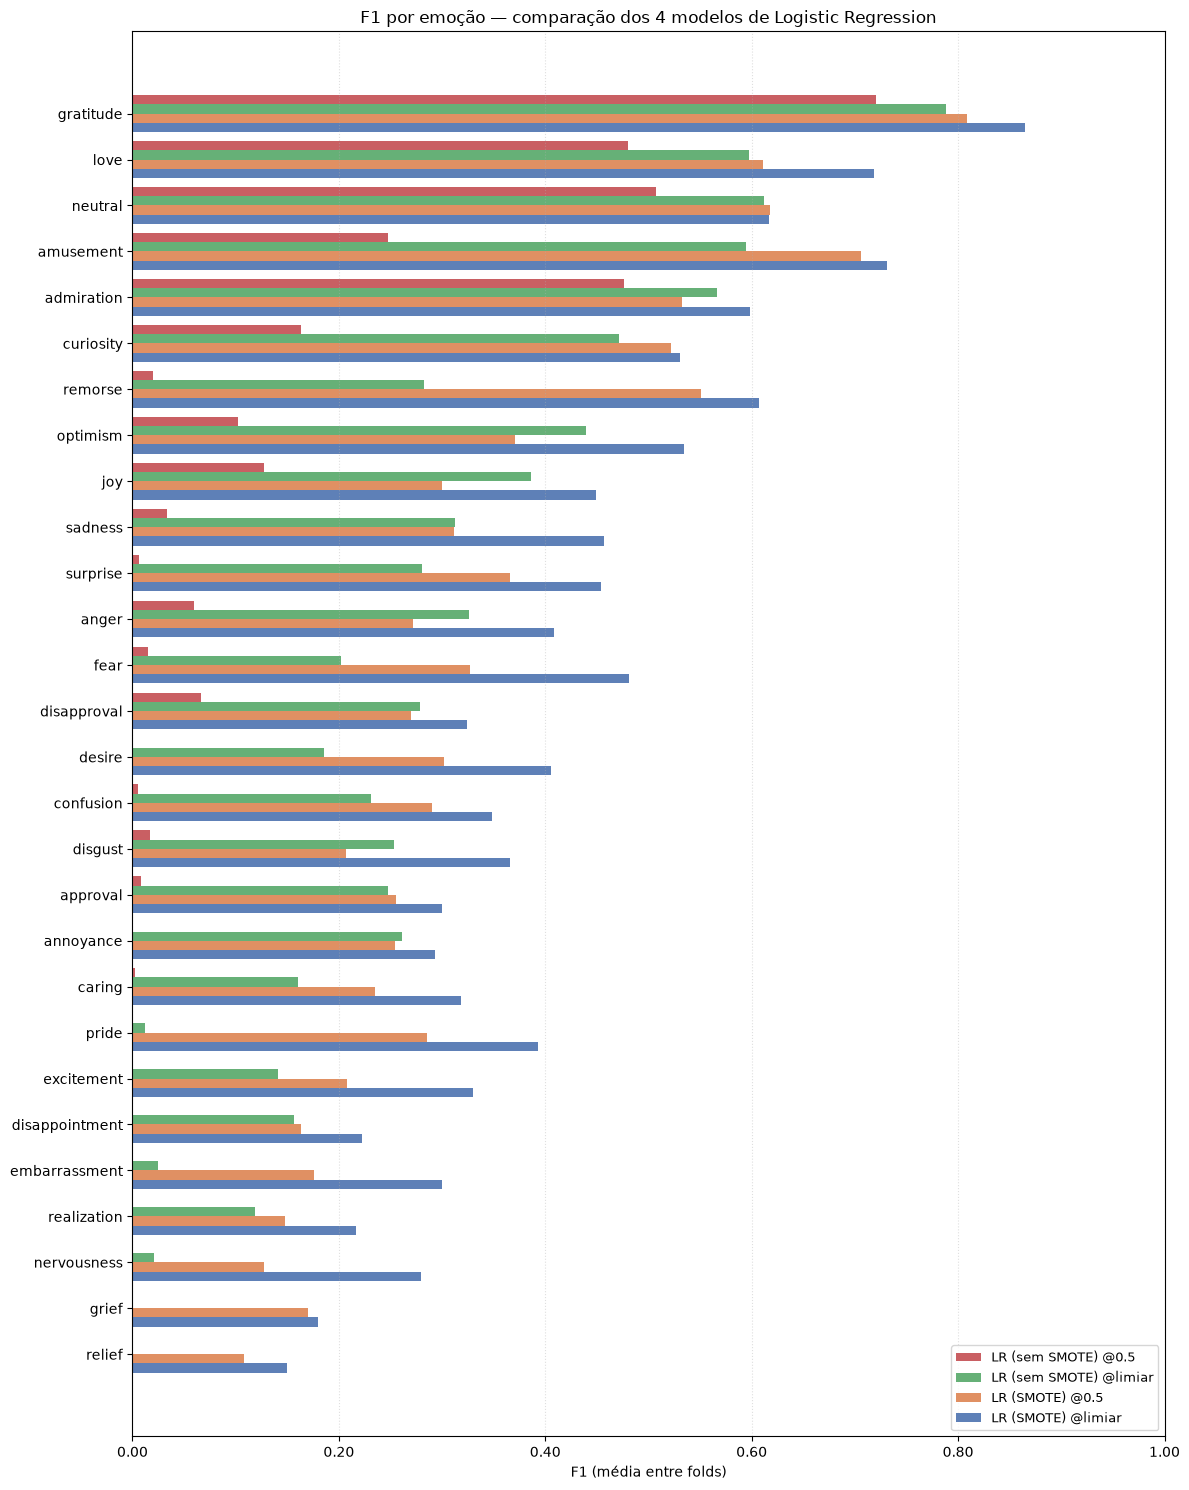

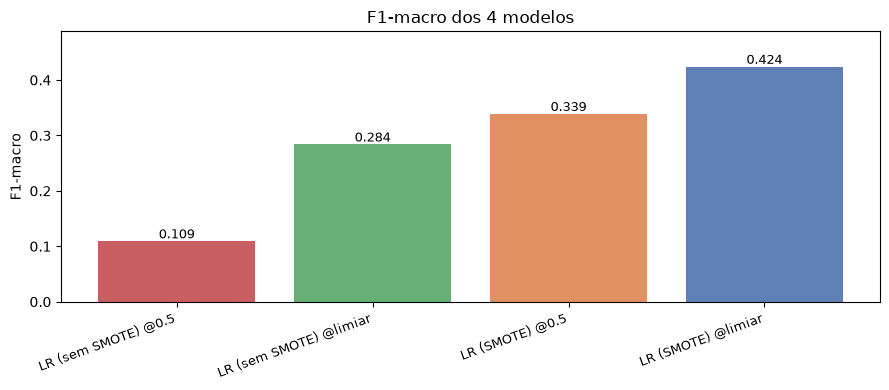

In [8]:
f1_per_label = {
    name: pd.DataFrame([m["f1_per_label"] for m in v]).mean()
    for name, v in model_fold_metrics.items()
}
df_f1_label = pd.DataFrame(f1_per_label)[list(MODEL_NAMES.values())]

# ordena emoções pela média dos 4 modelos (mais fácil -> mais difícil)
df_f1_label = df_f1_label.loc[df_f1_label.mean(axis=1).sort_values(ascending=False).index]

model_order = list(MODEL_NAMES.values())
colors = {
    "LR (sem SMOTE) @0.5"   : "#C44E52",
    "LR (sem SMOTE) @limiar": "#55A868",
    "LR (SMOTE) @0.5"       : "#DD8452",
    "LR (SMOTE) @limiar"    : "#4C72B0",
}

n_emo = df_f1_label.shape[0]
y = np.arange(n_emo)
height = 0.20

fig, ax = plt.subplots(figsize=(12, 15))
for i, name in enumerate(model_order):
    ax.barh(y + i * height, df_f1_label[name].values, height,
            label=name, color=colors[name], alpha=0.9)

ax.set_yticks(y + height * 1.5)
ax.set_yticklabels(df_f1_label.index)
ax.invert_yaxis()
ax.set_xlabel("F1 (média entre folds)")
ax.set_xlim(0, 1)
ax.set_title("F1 por emoção — comparação dos 4 modelos de Logistic Regression")
ax.legend(loc="lower right", fontsize=9)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(axis="x", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
macro = ranking.reindex(model_order)
ax.bar(range(len(macro)), macro.values,
       color=[colors[n] for n in macro.index], alpha=0.9)
ax.set_xticks(range(len(macro)))
ax.set_xticklabels(macro.index, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("F1-macro")
ax.set_ylim(0, max(macro.values) * 1.15)
for i, v in enumerate(macro.values):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
ax.set_title("F1-macro dos 4 modelos")
plt.tight_layout()
plt.show()

## Ablação — impacto das features adicionais

Aqui medimos o quanto as features extras ajudam, comparando três conjuntos de entrada (LR sem SMOTE, limiar calibrado por emoção, mesma nested CV):

- **`text_only`** — apenas TF-IDF (nenhuma feature adicional);
- **`all`** — TF-IDF + **todas** as features adicionais (reaproveita o treino já feito acima);
- **`no_sentiment`** — TF-IDF + features adicionais **exceto as de sentimento** (BERT, LeIA,
  OpLexicon, NRC EmoLex, VAD e `sent_disagreement`).

A diferença `all − no_sentiment` isola o efeito das features de **sentimento**; a diferença
`no_sentiment − text_only` mostra o efeito das demais features. Como cada `(conjunto, variant,
fold)` é um checkpoint separado, esta seção **retoma** o que já estiver em cache e só treina o que
falta.

> Observação: para manter o custo sob controle, a ablação usa apenas o variant **sem SMOTE** com
> **limiar calibrado** — o objetivo é isolar o efeito das *features*, não repetir a matriz 2×2.

In [9]:
ABLATION_SETS = {
    "text_only"   : [],
    "all"         : FEATURE_COLS_ALL,
    "no_sentiment": FEATURE_COLS_NO_SENT,
}

ablation_metrics = {}

for setname, feats in ABLATION_SETS.items():
    print(f"--- ablação: {setname} ({len(feats)} features) ---")
    P_folds, _ = run_nested_cv(setname, feats, use_smote=False)

    fold_metrics = []
    for k in range(1, N_OUTER_FOLDS + 1):
        train_ks = [j for j in range(1, N_OUTER_FOLDS + 1) if j != k]
        P_cal = np.vstack([P_folds[j] for j in train_ks])
        Y_cal = np.vstack([Y_folds[j] for j in train_ks])
        thr = calibrate_thresholds(P_cal, Y_cal, THRESH_GRID)
        m = metrics_at(Y_folds[k], P_folds[k], thr)
        m["outer_fold"] = k
        fold_metrics.append(m)
    ablation_metrics[setname] = fold_metrics

abl_frames = {name: folds_frame(v) for name, v in ablation_metrics.items()}
abl_rows = []
for name in ["text_only", "no_sentiment", "all"]:
    d = abl_frames[name]
    abl_rows.append({
        "Conjunto de features": name,
        "f1_macro": f"{d['f1_macro'].mean():.4f} ± {d['f1_macro'].std():.4f}",
        "f1_micro": f"{d['f1_micro'].mean():.4f}",
        "precision_macro": f"{d['precision_macro'].mean():.4f}",
        "recall_macro": f"{d['recall_macro'].mean():.4f}",
        "avg_precision_macro": f"{d['avg_precision_macro'].mean():.4f}",
    })
df_ablation = pd.DataFrame(abl_rows).set_index("Conjunto de features")

print("\n===== ABLAÇÃO — impacto das features (LR sem SMOTE, @limiar) =====")
display(df_ablation)

f1_text = abl_frames["text_only"]["f1_macro"].mean()
f1_nos  = abl_frames["no_sentiment"]["f1_macro"].mean()
f1_all  = abl_frames["all"]["f1_macro"].mean()
print(f"\nEfeito das features NÃO-sentimento : {f1_nos - f1_text:+.4f} (text_only -> no_sentiment)")
print(f"Efeito das features de SENTIMENTO  : {f1_all - f1_nos:+.4f} (no_sentiment -> all)")
print(f"Efeito TOTAL das features extras   : {f1_all - f1_text:+.4f} (text_only -> all)")

# Wilcoxon: sentimento agrega valor?
try:
    s, p = wilcoxon(abl_frames["all"]["f1_macro"].values,
                    abl_frames["no_sentiment"]["f1_macro"].values)
    print(f"\nWilcoxon (all vs no_sentiment): W={s:.1f}, p={p:.4f}")
except ValueError as e:
    print(f"\nWilcoxon N/A: {e}")

fig, ax = plt.subplots(figsize=(7, 4))
order = ["text_only", "no_sentiment", "all"]
vals = [abl_frames[n]["f1_macro"].mean() for n in order]
errs = [abl_frames[n]["f1_macro"].std() for n in order]
ax.bar(order, vals, yerr=errs, capsize=5,
       color=["#BBBBBB", "#DD8452", "#4C72B0"], alpha=0.9)
for i, v in enumerate(vals):
    ax.text(i, v + errs[i] + 0.004, f"{v:.3f}", ha="center", fontsize=10)
ax.set_ylabel("F1-macro")
ax.set_title("Ablação de features (LR sem SMOTE, @limiar)")
ax.set_ylim(0, max(vals) * 1.2)
plt.tight_layout()
plt.show()

--- ablação: text_only (0 features) ---
  [run ] text_only/nosmote fold 1 ...
        concluído em 319s -> checkpoint salvo
  [run ] text_only/nosmote fold 2 ...
        concluído em 343s -> checkpoint salvo
  [run ] text_only/nosmote fold 3 ...
        GridSearch pulado para 17/28 emoções (consenso >= 2 folds)
        concluído em 192s -> checkpoint salvo
  [run ] text_only/nosmote fold 4 ...
        GridSearch pulado para 25/28 emoções (consenso >= 2 folds)
        concluído em 104s -> checkpoint salvo
  [run ] text_only/nosmote fold 5 ...
        GridSearch pulado para 28/28 emoções (consenso >= 2 folds)
        concluído em 58s -> checkpoint salvo
--- ablação: all (36 features) ---
  [cache] all/nosmote fold 1
  [cache] all/nosmote fold 2
  [cache] all/nosmote fold 3
  [cache] all/nosmote fold 4
  [cache] all/nosmote fold 5
--- ablação: no_sentiment (22 features) ---
  [run ] no_sentiment/nosmote fold 1 ...


KeyboardInterrupt: 

## Hiperparâmetros por fold

In [10]:
PARAM_KEYS = ["features__txt__max_features", "features__txt__ngram_range",
              "features__txt__sublinear_tf", "lr__C"]

param_records = []
for variant, params_by_fold in PARAMS.items():
    for fold_k, label_dict in params_by_fold.items():
        for label, params in label_dict.items():
            row = {"variant": variant, "fold": fold_k, "label": label}
            row.update({pk: params.get(pk) for pk in PARAM_KEYS})
            param_records.append(row)

df_params = pd.DataFrame(param_records)

print("===== HIPERPARÂMETROS ESCOLHIDOS (contagem por variant) =====")
for variant in PARAMS:
    print(f"\n--- {variant} ---")
    sub = df_params[df_params["variant"] == variant]
    for pk in PARAM_KEYS:
        vc = sub[pk].astype(str).value_counts()
        print(f"  {pk}: {dict(vc)}")

# hiperparâmetro dominante por (variant, fold)
print("\n===== C mais frequente por (variant, fold) =====")
pivot_C = (
    df_params.assign(lr__C=df_params["lr__C"].astype(str))
    .pivot_table(index=["variant", "fold"], columns="lr__C",
                 values="label", aggfunc="count", fill_value=0)
)
display(pivot_C)

print("\n===== amostra da tabela completa de hiperparâmetros =====")
display(df_params.head(12))

===== HIPERPARÂMETROS ESCOLHIDOS (contagem por variant) =====

--- nosmote ---
  features__txt__max_features: {'30000.0': np.int64(136)}
  features__txt__ngram_range: {'[1, 1]': np.int64(128), '[1, 2]': np.int64(12)}
  features__txt__sublinear_tf: {'True': np.int64(140)}
  lr__C: {'10.0': np.int64(61), '0.1': np.int64(48), '1.0': np.int64(31)}

--- smote ---
  features__txt__max_features: {'30000.0': np.int64(128)}
  features__txt__ngram_range: {'[1, 2]': np.int64(48), '[1, 1]': np.int64(36), '(1, 2)': np.int64(29), '(1, 1)': np.int64(27)}
  features__txt__sublinear_tf: {'True': np.int64(140)}
  lr__C: {'10.0': np.int64(135), '1.0': np.int64(4), '0.1': np.int64(1)}

===== C mais frequente por (variant, fold) =====


lr__C         0.1  1.0  10.0
variant fold                
nosmote 1       6    9    13
        2      11    5    12
        3      12    3    13
        4       8    7    13
        5      11    7    10
smote   1       1    1    26
        2       0    0    28
        3       0    0    28
        4       0    2    26
        5       0    1    27


===== amostra da tabela completa de hiperparâmetros =====


,variant,fold,label,features__txt__max_features,features__txt__ngram_range,features__txt__sublinear_tf,lr__C
0,nosmote,1,admiration,30000.0,"[1, 1]",True,10.0
1,nosmote,1,amusement,30000.0,"[1, 1]",True,10.0
2,nosmote,1,anger,30000.0,"[1, 1]",True,10.0
3,nosmote,1,annoyance,30000.0,"[1, 1]",True,10.0
4,nosmote,1,approval,30000.0,"[1, 1]",True,10.0
5,nosmote,1,caring,30000.0,"[1, 2]",True,1.0
6,nosmote,1,confusion,30000.0,"[1, 2]",True,10.0
7,nosmote,1,curiosity,30000.0,"[1, 1]",True,1.0
8,nosmote,1,desire,30000.0,"[1, 1]",True,1.0
9,nosmote,1,disappointment,30000.0,"[1, 1]",True,0.1


## Exportação dos resultados

In [11]:
rows_global = []
for name, d in model_frames.items():
    for fold in d.index:
        rec = {"modelo": name, "outer_fold": fold}
        rec.update({c: d.loc[fold, c] for c in SUMMARY_KEYS})
        rows_global.append(rec)
pd.DataFrame(rows_global).to_csv(OUT_DIR / "baseline_LR_4models_metrics.csv", index=False)

df_f1_label.to_csv(OUT_DIR / "baseline_LR_4models_f1_per_label.csv")

df_params.to_csv(OUT_DIR / "baseline_LR_best_params.csv", index=False)

thr_rows = {}
for variant in thresholds_store:
    thr_rows[variant] = pd.DataFrame(
        {k: thresholds_store[variant][k] for k in thresholds_store[variant]},
        index=EMOTION_COLS,
    ).mean(axis=1)
df_thr = pd.DataFrame(thr_rows)
df_thr["base_rate"] = base_rates.reindex(EMOTION_COLS)
df_thr.to_csv(OUT_DIR / "baseline_LR_thresholds_por_emocao.csv")

pd.DataFrame({
    name: folds_frame(v)["f1_macro"] for name, v in ablation_metrics.items()
}).to_csv(OUT_DIR / "baseline_LR_ablacao_f1_macro.csv")

summary = {
    "modelo": "LogisticRegression + TF-IDF + features adicionais (Binary Relevance)",
    "estrategia": "Nested CV (5 outer / 3 inner), 2 treinos (com/sem SMOTE) x 2 limiares (0.5/calibrado)",
    "n_labels": N_LABELS,
    "n_features_extra": len(FEATURE_COLS_ALL),
    "n_features_sentimento": len(FEATURE_COLS_SENT),
    "grade_limiar": [float(THRESH_GRID.min()), float(THRESH_GRID.max()), int(len(THRESH_GRID))],
    "resultados_4_modelos": {
        name: {
            "f1_macro": f"{d['f1_macro'].mean():.4f} +/- {d['f1_macro'].std():.4f}",
            "f1_micro": f"{d['f1_micro'].mean():.4f}",
            "precision_macro": f"{d['precision_macro'].mean():.4f}",
            "recall_macro": f"{d['recall_macro'].mean():.4f}",
            "avg_precision_macro": f"{d['avg_precision_macro'].mean():.4f}",
            "roc_auc_macro": f"{d['roc_auc_macro'].mean():.4f}",
        } for name, d in model_frames.items()
    },
    "ablacao_f1_macro": {
        name: f"{folds_frame(v)['f1_macro'].mean():.4f}"
        for name, v in ablation_metrics.items()
    },
    "nota_vazamento": (
        "TF-IDF, StandardScaler e SMOTE sao 'fit' apenas no treino (SMOTE so no inner-train "
        "dentro do GridSearch). Limiares calibrados em folds j!=k (OOF), nunca no fold de teste. "
        "Features densas foram calculadas linha-a-linha no data_preprocessing (sem estatistica "
        "do corpus)."
    ),
}
with open(OUT_DIR / "baseline_LR_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Arquivos exportados para", OUT_DIR.resolve())
print(json.dumps(summary, indent=2, ensure_ascii=False))

Arquivos exportados para C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\baseline_LR
{
  "modelo": "LogisticRegression + TF-IDF + features adicionais (Binary Relevance)",
  "estrategia": "Nested CV (5 outer / 3 inner), 2 treinos (com/sem SMOTE) x 2 limiares (0.5/calibrado)",
  "n_labels": 28,
  "n_features_extra": 36,
  "n_features_sentimento": 14,
  "grade_limiar": [
    0.05,
    0.95,
    19
  ],
  "resultados_4_modelos": {
    "LR (sem SMOTE) @0.5": {
      "f1_macro": "0.1093 +/- 0.0018",
      "f1_micro": "0.3190",
      "precision_macro": "0.3740",
      "recall_macro": "0.0776",
      "avg_precision_macro": "0.2488",
      "roc_auc_macro": "0.8261"
    },
    "LR (sem SMOTE) @limiar": {
      "f1_macro": "0.2840 +/- 0.0045",
      "f1_micro": "0.4212",
      "precision_macro": "0.2847",
      "recall_macro": "0.3311",
      "avg_precision_macro": "0.2488",
      "roc_auc_macro": "0.8261"
    },
    "LR (SMOTE) @0.5": {
      "f1_macro":

## Análise de Erros por Emoção — Fusão com Ekman

Para as emoções com F1 mais baixo, investigamos se o modelo as "confunde"
dentro do mesmo grupo de Ekman (ex.: confundir `grief` com `sadness`).
Se for esse o caso, **fundir** essas emoções no label pai de Ekman recupera
F1 sem perder informação relevante para o consultor.

A célula abaixo gera um **arquivo HTML** para explorar:
- F1 por emoção do melhor modelo
- Grupo de Ekman de cada emoção
- Matriz de confusão *multi-label* (co-ocorrências reais vs preditas) dentro
  de cada grupo
- Simulação do F1 após fusão (o que acontece se trocar N emoções pelo label
  do grupo pai)

In [12]:
import json
from pathlib import Path

EKMAN_MAP = {
    "anger"  : ["anger", "annoyance", "disapproval"],
    "disgust": ["disgust"],
    "fear"   : ["fear", "nervousness"],
    "joy"    : ["joy", "amusement", "approval", "excitement", "gratitude",
                "love", "optimism", "relief", "pride", "admiration",
                "desire", "caring"],
    "sadness": ["sadness", "disappointment", "embarrassment", "grief", "remorse"],
    "surprise": ["surprise", "realization", "confusion", "curiosity"],
}
EMO_TO_EKMAN = {emo: grp for grp, emos in EKMAN_MAP.items() for emo in emos}

best_model_name = ranking.index[0]
best_metrics    = model_fold_metrics[best_model_name]

f1_best = pd.DataFrame([m["f1_per_label"] for m in best_metrics]).mean()
f1_best = f1_best.reindex(EMOTION_COLS)

_variant = "smote" if "SMOTE" in best_model_name else "nosmote"
_tuned   = "@limiar" in best_model_name
P_best   = PROBA[_variant]

Y_true_all = np.vstack([Y_folds[k] for k in range(1, N_OUTER_FOLDS + 1)])
P_all      = np.vstack([P_best[k]  for k in range(1, N_OUTER_FOLDS + 1)])

if _tuned:
    thr_mean = np.vstack(
        [thresholds_store[_variant][k] for k in range(1, N_OUTER_FOLDS + 1)]
    ).mean(axis=0)
else:
    thr_mean = np.full(N_LABELS, FIXED_THRESHOLD)

Y_pred_all = (P_all >= thr_mean[None, :]).astype(int)

def cooccurrence_within_group(group_emos):
    idx = [EMOTION_COLS.index(e) for e in group_emos if e in EMOTION_COLS]
    n   = len(idx)
    co  = {"true": {}, "pred": {}}
    for ii, i in enumerate(idx):
        for jj, j in enumerate(idx):
            if i == j:
                continue
            # y_true[:,i]=1 E y_true[:,j]=1
            co["true"][(EMOTION_COLS[i], EMOTION_COLS[j])] = int(
                (Y_true_all[:, i] & Y_true_all[:, j]).sum()
            )
            # y_true[:,i]=1 E y_pred[:,j]=1  (modelo "acerta via vizinha")
            co["pred"][(EMOTION_COLS[i], EMOTION_COLS[j])] = int(
                (Y_true_all[:, i] & Y_pred_all[:, j]).sum()
            )
    return co

def simulate_merge(group_name, group_emos):
    in_group  = [e for e in group_emos if e in EMOTION_COLS]
    out_group = [e for e in EMOTION_COLS if e not in set(in_group)
                 and e in EMO_TO_EKMAN]   # exclui 'neutral'

    idx_in  = [EMOTION_COLS.index(e) for e in in_group]
    idx_out = [EMOTION_COLS.index(e) for e in out_group]

    f1_orig_group = f1_score(
        Y_true_all[:, idx_in],
        Y_pred_all[:, idx_in],
        average=None, zero_division=0,
    )

    y_true_merged = Y_true_all[:, idx_in].max(axis=1)
    y_pred_merged = Y_pred_all[:, idx_in].max(axis=1)
    f1_merged = f1_score(y_true_merged, y_pred_merged, zero_division=0)

    Y_true_new = np.hstack([Y_true_all[:, idx_out], y_true_merged[:, None]])
    Y_pred_new = np.hstack([Y_pred_all[:, idx_out], y_pred_merged[:, None]])
    f1_global_fused = f1_score(Y_true_new, Y_pred_new, average="macro", zero_division=0)

    idx_all_mapped = idx_in + idx_out
    f1_global_orig = f1_score(
        Y_true_all[:, idx_all_mapped],
        Y_pred_all[:, idx_all_mapped],
        average="macro", zero_division=0,
    )

    return {
        "f1_orig_per_emo"  : {e: float(round(f, 4)) for e, f in zip(in_group, f1_orig_group)},
        "f1_merged"        : round(float(f1_merged), 4),
        "f1_global_orig"   : round(float(f1_global_orig), 4),
        "f1_global_fused"  : round(float(f1_global_fused), 4),
        "delta_global"     : round(float(f1_global_fused - f1_global_orig), 4),
    }

payload = {
    "best_model"  : best_model_name,
    "ekman_map"   : EKMAN_MAP,
    "emo_to_ekman": EMO_TO_EKMAN,
    "f1_per_emo"  : {e: round(float(f1_best[e]), 4) for e in EMOTION_COLS},
    "groups"      : {},
}

for grp, emos in EKMAN_MAP.items():
    in_vocab = [e for e in emos if e in EMOTION_COLS]
    co       = cooccurrence_within_group(in_vocab)
    sim      = simulate_merge(grp, in_vocab)
    payload["groups"][grp] = {
        "emos"      : in_vocab,
        "f1_each"   : {e: round(float(f1_best[e]), 4) for e in in_vocab},
        "f1_mean"   : round(float(np.mean([f1_best[e] for e in in_vocab])), 4),
        "cooccur"   : {f"{a}|{b}": v for (a, b), v in co["true"].items()},
        "cooccur_pred": {f"{a}|{b}": v for (a, b), v in co["pred"].items()},
        "merge_sim" : sim,
    }

data_js = json.dumps(payload, ensure_ascii=False)

HTML = """<!DOCTYPE html>
<html lang="pt-BR">
<head>
<meta charset="UTF-8">
<title>Análise de Erros — Ekman × GoEmotions</title>
<style>
  *{box-sizing:border-box;margin:0;padding:0}
  body{font-family:"Segoe UI",Arial,sans-serif;background:#f5f6fa;color:#222;padding:24px}
  h1{font-size:1.35rem;margin-bottom:4px}
  .subtitle{color:#666;font-size:.9rem;margin-bottom:20px}
  .card{background:#fff;border-radius:8px;box-shadow:0 1px 4px rgba(0,0,0,.1);
        margin-bottom:20px;overflow:hidden}
  .card-header{padding:12px 16px;display:flex;align-items:center;gap:12px;cursor:pointer;
               user-select:none}
  .card-header:hover{background:#fafbff}
  .ekman-badge{display:inline-block;padding:2px 9px;border-radius:12px;font-size:.75rem;
               font-weight:700;color:#fff;white-space:nowrap}
  .card-body{padding:16px;border-top:1px solid #eee;display:none}
  .card.open .card-body{display:block}
  .chevron{margin-left:auto;font-size:1rem;transition:transform .2s}
  .card.open .chevron{transform:rotate(180deg)}
  /* F1 bars */
  .emo-row{display:flex;align-items:center;gap:8px;margin-bottom:7px}
  .emo-name{width:130px;font-size:.82rem;white-space:nowrap;overflow:hidden;
             text-overflow:ellipsis}
  .bar-bg{flex:1;background:#e9ecef;border-radius:4px;height:14px;position:relative}
  .bar-fill{height:100%;border-radius:4px;transition:width .3s}
  .bar-val{position:absolute;right:4px;top:0;font-size:.7rem;line-height:14px;color:#444}
  /* Merge box */
  .merge-box{background:#f8f9ff;border:1px solid #dde;border-radius:6px;
             padding:12px 14px;margin-top:14px;font-size:.84rem}
  .merge-box h4{margin-bottom:6px;font-size:.88rem;color:#3a3f8f}
  .delta{font-weight:700}
  .delta.pos{color:#2a7a2a}.delta.neg{color:#c0392b}.delta.neu{color:#888}
  /* Co-occurrence table */
  .co-section{margin-top:14px}
  .co-section h4{font-size:.88rem;color:#555;margin-bottom:6px}
  table{border-collapse:collapse;width:100%;font-size:.78rem}
  th,td{border:1px solid #ddd;padding:5px 8px;text-align:center}
  th{background:#f0f0f0;font-weight:600}
  td.row-label{text-align:left;font-weight:600;background:#fafafa}
  .heat0{background:#fff}.heat1{background:#ddeeff}.heat2{background:#99ccee}
  .heat3{background:#4499cc;color:#fff}.heat4{background:#005588;color:#fff}
  /* controls */
  .controls{margin-bottom:16px;display:flex;gap:12px;align-items:center;flex-wrap:wrap}
  select,input{padding:5px 8px;border:1px solid #ccc;border-radius:5px;font-size:.85rem}
  label{font-size:.85rem;color:#444}
  .top-f1{margin-bottom:16px}
  .top-f1 h3{font-size:.95rem;margin-bottom:6px;color:#333}
  /* bottom worst table */
  .worst-table td,.worst-table th{padding:4px 10px}
  .ekman-tag{font-size:.7rem;padding:1px 6px;border-radius:10px;color:#fff;
             display:inline-block;vertical-align:middle;margin-left:4px}
</style>
</head>
<body>
<h1>Análise de Erros — GoEmotions × Ekman</h1>
<div class="subtitle" id="subtitle"></div>

<div class="controls">
  <label>Ordenar grupos por:
    <select id="sortGroups">
      <option value="f1_mean">F1-médio do grupo (↑)</option>
      <option value="f1_mean_desc">F1-médio do grupo (↓)</option>
      <option value="delta">Ganho de fusão (↑)</option>
      <option value="alpha">Ordem alfabética</option>
    </select>
  </label>
  <label>Pior N emoções:
    <input type="number" id="worstN" value="8" min="2" max="28" style="width:60px">
  </label>
  <button onclick="renderAll()" style="padding:5px 12px;cursor:pointer">Atualizar</button>
</div>

<div class="top-f1">
  <h3>Emoções com menor F1 (melhor modelo OOF)</h3>
  <div id="worstTable"></div>
</div>

<div id="groups"></div>

<script>
const D = __DATA__;

const EKMAN_COLORS = {
  anger:"#e74c3c", disgust:"#8e44ad", fear:"#e67e22",
  joy:"#f1c40f", sadness:"#3498db", surprise:"#1abc9c"
};

function heat(v, max) {
  if (max === 0) return "heat0";
  const r = v / max;
  if (r < 0.01) return "heat0";
  if (r < 0.25) return "heat1";
  if (r < 0.50) return "heat2";
  if (r < 0.75) return "heat3";
  return "heat4";
}

function ekmanBadge(grp) {
  const c = EKMAN_COLORS[grp] || "#888";
  return `<span class="ekman-badge" style="background:${c}">${grp}</span>`;
}

function renderWorstTable(n) {
  const entries = Object.entries(D.f1_per_emo)
    .sort((a,b) => a[1]-b[1]).slice(0, n);
  let html = `<table class="worst-table"><tr><th>#</th><th>Emoção</th><th>Grupo Ekman</th>
    <th>F1</th><th>F1 fundido*</th><th>Δ global**</th></tr>`;
  entries.forEach(([emo, f1], i) => {
    const grp = D.emo_to_ekman[emo] || "—";
    const c   = EKMAN_COLORS[grp]  || "#888";
    const mg  = D.groups[grp] ? D.groups[grp].merge_sim : null;
    const f1m = mg ? mg.f1_merged.toFixed(4) : "—";
    const dg  = mg ? mg.delta_global : null;
    const dg_str = dg != null ? (dg >= 0 ? `+${dg.toFixed(4)}` : dg.toFixed(4)) : "—";
    const dg_cls = dg != null ? (dg > 0.001 ? "pos" : dg < -0.001 ? "neg" : "neu") : "";
    html += `<tr>
      <td>${i+1}</td>
      <td><strong>${emo}</strong></td>
      <td><span class="ekman-badge" style="background:${c}">${grp}</span></td>
      <td>${f1.toFixed(4)}</td>
      <td>${f1m}</td>
      <td class="delta ${dg_cls}">${dg_str}</td>
    </tr>`;
  });
  html += `</table>
  <p style="font-size:.75rem;color:#888;margin-top:6px">
  * F1 do label fundido = OR das emoções do mesmo grupo de Ekman.
  ** Δ global = F1-macro geral com fusão − F1-macro geral sem fusão (emoções mapeadas, sem neutral).</p>`;
  document.getElementById("worstTable").innerHTML = html;
}

function renderGroup(grp, info) {
  const c = EKMAN_COLORS[grp] || "#888";
  const sim = info.merge_sim;
  const delta = sim.delta_global;
  const dCls  = delta > 0.001 ? "pos" : delta < -0.001 ? "neg" : "neu";
  const dStr  = (delta >= 0 ? "+" : "") + delta.toFixed(4);

  // F1 bars
  let bars = "";
  const sortedEmos = Object.entries(info.f1_each).sort((a,b) => a[1]-b[1]);
  sortedEmos.forEach(([emo, f1]) => {
    const pct = (f1*100).toFixed(1);
    bars += `<div class="emo-row">
      <div class="emo-name" title="${emo}">${emo}</div>
      <div class="bar-bg">
        <div class="bar-fill" style="width:${pct}%;background:${c}88"></div>
        <span class="bar-val">${f1.toFixed(3)}</span>
      </div>
    </div>`;
  });

  // Co-occurrence table (true)
  const emos = info.emos;
  let coHdr = `<tr><th>real↓ / pred→</th>` + emos.map(e=>`<th>${e}</th>`).join("") + `</tr>`;
  let coRows = "";
  // max value for heatmap
  let maxCo = 0;
  emos.forEach(a => emos.forEach(b => {
    if (a===b) return;
    maxCo = Math.max(maxCo, info.cooccur_pred[`${a}|${b}`] || 0);
  }));
  emos.forEach(a => {
    coRows += `<tr><td class="row-label">${a}</td>`;
    emos.forEach(b => {
      if (a === b) { coRows += `<td style="background:#f0f0f0">—</td>`; return; }
      const v = info.cooccur_pred[`${a}|${b}`] || 0;
      coRows += `<td class="${heat(v, maxCo)}">${v}</td>`;
    });
    coRows += `</tr>`;
  });

  // merge box
  const origList = Object.entries(sim.f1_orig_per_emo)
    .map(([e,f]) => `<span title="${e}">${e}: <b>${f.toFixed(3)}</b></span>`).join(" · ");

  const html = `
    <div style="font-size:.83rem;color:#555;margin-bottom:10px">
      F1-médio do grupo: <b>${info.f1_mean.toFixed(3)}</b>
      &nbsp;|&nbsp; ${emos.length} emoções
    </div>
    ${bars}
    <div class="merge-box">
      <h4>Simulação de fusão: OR(${emos.join(", ")}) → <em>${grp}</em></h4>
      <p style="margin-bottom:6px">${origList}</p>
      <p>F1 fundido (label único): <b>${sim.f1_merged.toFixed(4)}</b></p>
      <p>F1-macro global <em>sem</em> fusão: <b>${sim.f1_global_orig.toFixed(4)}</b>
         &nbsp;→&nbsp; <em>com</em> fusão: <b>${sim.f1_global_fused.toFixed(4)}</b>
         &nbsp; Δ = <span class="delta ${dCls}">${dStr}</span></p>
      <p style="font-size:.75rem;color:#888;margin-top:6px">
        Fusão: toma OR de Y_true e Y_pred nas colunas do grupo. Exclui "neutral" do cálculo.
      </p>
    </div>
    ${emos.length > 1 ? `
    <div class="co-section">
      <h4>Co-ocorrências preditas dentro do grupo
          <span style="font-size:.75rem;font-weight:400">(linha = real=1; coluna = pred=1; mais escuro = mais frequente)</span>
      </h4>
      <table>${coHdr}${coRows}</table>
    </div>` : ""}
  `;
  return html;
}

function sortedGroupKeys() {
  const sortBy = document.getElementById("sortGroups").value;
  const keys = Object.keys(D.groups);
  if (sortBy === "alpha")        return keys.sort();
  if (sortBy === "f1_mean_desc") return keys.sort((a,b) => D.groups[b].f1_mean - D.groups[a].f1_mean);
  if (sortBy === "f1_mean")      return keys.sort((a,b) => D.groups[a].f1_mean - D.groups[b].f1_mean);
  if (sortBy === "delta")        return keys.sort((a,b) =>
      D.groups[b].merge_sim.delta_global - D.groups[a].merge_sim.delta_global);
  return keys;
}

function renderAll() {
  const n = parseInt(document.getElementById("worstN").value) || 8;
  renderWorstTable(n);

  const container = document.getElementById("groups");
  container.innerHTML = "";
  sortedGroupKeys().forEach(grp => {
    const info = D.groups[grp];
    const c    = EKMAN_COLORS[grp] || "#888";
    const delta = info.merge_sim.delta_global;
    const dCls  = delta > 0.001 ? "pos" : delta < -0.001 ? "neg" : "neu";
    const dStr  = (delta >= 0 ? "+" : "") + delta.toFixed(4);
    const div   = document.createElement("div");
    div.className = "card";
    div.innerHTML = `
      <div class="card-header" onclick="this.parentElement.classList.toggle('open')">
        ${ekmanBadge(grp)}
        <span style="font-size:.9rem;font-weight:600">${grp.toUpperCase()}</span>
        <span style="font-size:.82rem;color:#666">&nbsp;·&nbsp; F1-médio ${info.f1_mean.toFixed(3)}
          &nbsp;|&nbsp; fusão Δ = <span class="delta ${dCls}">${dStr}</span></span>
        <span class="chevron">▼</span>
      </div>
      <div class="card-body">${renderGroup(grp, info)}</div>`;
    container.appendChild(div);
  });
}

// auto-expand the worst group
function init() {
  document.getElementById("subtitle").textContent =
    "Melhor modelo: " + D.best_model + " — OOF (probabilidades fora do fold de treino)";
  renderAll();
  // auto-expand the group with lowest F1-mean
  const worst = Object.entries(D.groups).sort((a,b)=>a[1].f1_mean-b[1].f1_mean)[0][0];
  const cards = document.querySelectorAll(".card");
  cards.forEach(c => {
    if (c.querySelector(".card-header span:nth-child(2)")?.textContent.trim().toLowerCase() === worst)
      c.classList.add("open");
  });
}
init();
</script>
</body>
</html>
"""

html_out = HTML.replace("__DATA__", data_js)
out_path = OUT_DIR / "ekman_error_analysis.html"
out_path.write_text(html_out, encoding="utf-8")
print(f"✓ HTML salvo em: {out_path.resolve()}")
print(f"  Abra no browser para explorar os {len(EKMAN_MAP)} grupos de Ekman.")
print()

print("===== RESUMO: ganho de fusão por grupo de Ekman =====")
print(f"{'Grupo':<10} {'F1-médio':>9} {'F1-fundido':>11} {'Δ-global':>10}  emoções")
for grp in sorted(payload["groups"], key=lambda g: payload["groups"][g]["merge_sim"]["delta_global"], reverse=True):
    g = payload["groups"][grp]
    s = g["merge_sim"]
    sign = "+" if s["delta_global"] >= 0 else ""
    print(f"{grp:<10} {g['f1_mean']:>9.4f} {s['f1_merged']:>11.4f} "
          f"{sign}{s['delta_global']:>9.4f}  {', '.join(g['emos'])}")

✓ HTML salvo em: C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\baseline_LR\ekman_error_analysis.html
  Abra no browser para explorar os 6 grupos de Ekman.

===== RESUMO: ganho de fusão por grupo de Ekman =====
Grupo       F1-médio  F1-fundido   Δ-global  emoções
sadness       0.3533      0.4942 +   0.0168  sadness, disappointment, embarrassment, grief, remorse
anger         0.3416      0.4691 +   0.0115  anger, annoyance, disapproval
surprise      0.3873      0.5402 +   0.0103  surprise, realization, confusion, curiosity
fear          0.3803      0.4865 +   0.0055  fear, nervousness
disgust       0.3660      0.3661 +   0.0000  disgust
joy           0.4828      0.7502   -0.0302  joy, amusement, approval, excitement, gratitude, love, optimism, relief, pride, admiration, desire, caring
